<a href="https://colab.research.google.com/github/MrinalPradhan675/coe311k/blob/main/mp53349_ch9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Slope: 0.9500000000000001
Intercept: 0.5900000000000001


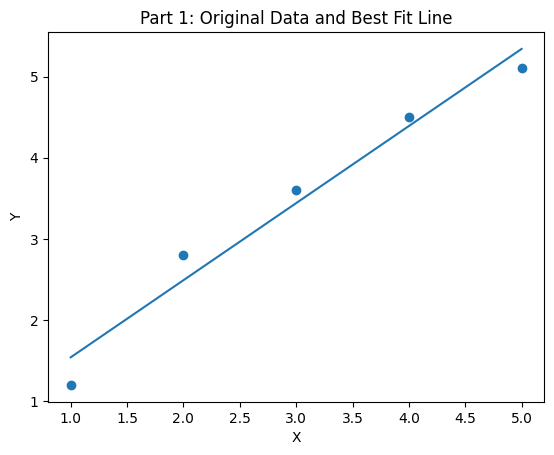

Slope: -0.37000000000000033
Intercept: 4.550000000000003


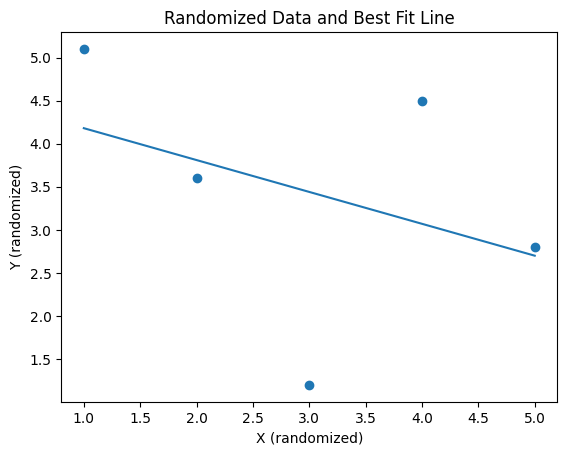

True slope: 2.3
True intercept: -0.7
Recovered slope: 2.317209102055045
Recovered intercept: -0.71693622815512


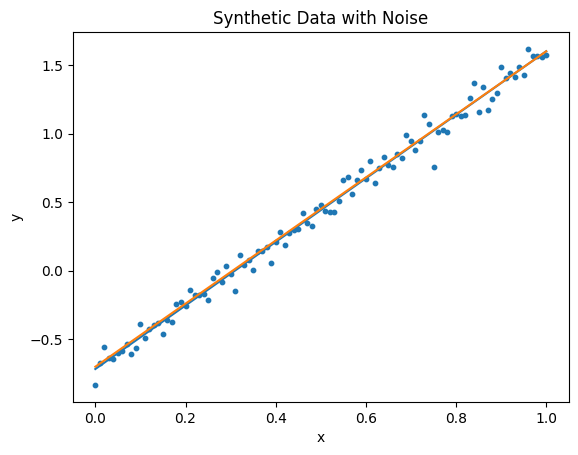

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# Data points
X = np.array([1, 2, 3, 4, 5], dtype=float)
Y = np.array([1.2, 2.8, 3.6, 4.5, 5.1], dtype=float)

# Design matrix
A = np.vstack([X, np.ones(len(X))]).T

# Least squares solution
m, c = np.linalg.lstsq(A, Y, rcond=None)[0]

print("Slope:", m)
print("Intercept:", c)

# Plot
xLine = np.linspace(min(X), max(X), 200)
yLine = m * x_line + c

plt.figure()
plt.scatter(X, Y)
plt.plot(xLine, yLine)
plt.title("Part 1: Original Data and Best Fit Line")
plt.xlabel("X")
plt.ylabel("Y")
plt.show()

# Randomize independently
rng = np.random.default_rng()
xRand = X.copy()
yRand = Y.copy()
rng.shuffle(xRand)
rng.shuffle(yRand)

A2 = np.vstack([xRand, np.ones(len(xRand))]).T
m2, c2 = np.linalg.lstsq(A2, yRand, rcond=None)[0]

print("Slope:", m2)
print("Intercept:", c2)

xLine2 = np.linspace(min(xRand), max(xRand), 200)
yLine2 = m2 * xLine2 + c2

#Plot
plt.figure()
plt.scatter(xRand, yRand)
plt.plot(xLine2, yLine2)
plt.title("Randomized Data and Best Fit Line")
plt.xlabel("X (randomized)")
plt.ylabel("Y (randomized)")
plt.show()

# When X and Y are randomized independently, it brakes the original pairing between each x value and its corresponding y value. Least squares still finds the best possible line for the new data, but since there is no longer a real linear relationship, the fit becomes weak or even misleading.

# True linear equation
m_true = 2.3
c_true = -0.7

# Generate x values
x3 = np.arange(0, 1.01, 0.01)

# Add random noise
noise = rng.normal(0, 0.07, len(x3))
y3 = m_true * x3 + c_true + noise

# Least squares on noisy data
A3 = np.vstack([x3, np.ones(len(x3))]).T
m3, c3 = np.linalg.lstsq(A3, y3, rcond=None)[0]

print("True slope:", m_true)
print("True intercept:", c_true)
print("Recovered slope:", m3)
print("Recovered intercept:", c3)

# Plot
xLine3 = np.linspace(0, 1, 200)
yFit3 = m3 * xLine3 + c3
yTrue3 = m_true * xLine3 + c_true

plt.figure()
plt.scatter(x3, y3, s=10)
plt.plot(xLine3, yFit3)
plt.plot(xLine3, yTrue3)
plt.title("Synthetic Data with Noise")
plt.xlabel("x")
plt.ylabel("y")
plt.show()